## Read raw data into pandas

## Configuration

In [1]:
# ---------------------------------------------------------------------------
# Change DATA_VARIANT to switch between full and small datasets.
#   ""       → raw_profiles.csv / parsed_experiences.csv / classified_jobs_gemini.csv
#   "_small" → raw_profiles_small.csv / parsed_experiences_small.csv / classified_jobs_gemini_small.csv
# ---------------------------------------------------------------------------
DATA_VARIANT = ""  # set to "_small" for the small dataset

RAW_INPUT          = f"../data/raw/raw_profiles{DATA_VARIANT}.csv"
PARSED_OUTPUT      = f"../data/processed/parsed_experiences{DATA_VARIANT}.csv"
CLASSIFIED_OUTPUT  = f"../data/processed/classified_jobs_gemini{DATA_VARIANT}.csv"
SENIORITY_OUTPUT   = f"../data/processed/classified_jobs_gemini_seniority{DATA_VARIANT}.csv"
DURATION_OUTPUT    = f"../data/processed/classified_jobs_gemini_duration{DATA_VARIANT}.csv"
PROFILE_OUTPUT     = f"../data/processed/classified_jobs_gemini_profiles{DATA_VARIANT}.csv"

# ---------------------------------------------------------------------------
# Set to False to skip a step (e.g. if its output file already exists).
# ---------------------------------------------------------------------------
RUN_PARSING        = False   # parse raw profiles → parsed_experiences
RUN_CLASSIFICATION = False   # classify job titles → classified_jobs_gemini
RUN_SENIORITY      = False   # assign seniority levels → classified_jobs_gemini_seniority
RUN_DURATION       = False   # calculate role durations → classified_jobs_gemini_duration
RUN_PROFILES       = False   # classify profiles → classified_jobs_gemini_profiles

print(f"Using dataset variant: '{DATA_VARIANT or 'full'}'")
print(f"  Raw input:          {RAW_INPUT}")
print(f"  Parsed output:      {PARSED_OUTPUT}")
print(f"  Classified output:  {CLASSIFIED_OUTPUT}")
print(f"  Seniority output:   {SENIORITY_OUTPUT}")
print(f"  Duration output:    {DURATION_OUTPUT}")
print(f"  Profile output:     {PROFILE_OUTPUT}")
print()
print(f"Steps to run:")
print(f"  Parsing:        {'ON' if RUN_PARSING else 'SKIP'}")
print(f"  Classification: {'ON' if RUN_CLASSIFICATION else 'SKIP'}")
print(f"  Seniority:      {'ON' if RUN_SENIORITY else 'SKIP'}")
print(f"  Duration:       {'ON' if RUN_DURATION else 'SKIP'}")
print(f"  Profiles:       {'ON' if RUN_PROFILES else 'SKIP'}")

Using dataset variant: 'full'
  Raw input:          ../data/raw/raw_profiles.csv
  Parsed output:      ../data/processed/parsed_experiences.csv
  Classified output:  ../data/processed/classified_jobs_gemini.csv
  Seniority output:   ../data/processed/classified_jobs_gemini_seniority.csv
  Duration output:    ../data/processed/classified_jobs_gemini_duration.csv
  Profile output:     ../data/processed/classified_jobs_gemini_profiles.csv

Steps to run:
  Parsing:        SKIP
  Classification: SKIP
  Seniority:      SKIP
  Duration:       SKIP
  Profiles:       SKIP


In [ ]:
import pandas as pd

raw = pd.read_csv(RAW_INPUT)
raw.head()

## Define the experience data class
The experience data class will correspond to one row in the resulting csv.

In [ ]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class Experience:
    """Represents a single work experience entry from a LinkedIn profile.
    
    Designed to map directly to a CSV row.
    """
    profile_id: int
    job_title: str
    country: Optional[str]
    start_date: Optional[str]  # e.g. "2020-01" or "Jan 2020"
    end_date: Optional[str]    # None means present/current role
    company: Optional[str] = None  # Optional field for company name
    position_in_career: Optional[int] = None  # Optional field for position in career timeline

## Format the Experiences
Format the existing experiences in the format that matches the experience data class.

In [ ]:
import os
import json
import time
import re

from google import genai
from google.genai.errors import ClientError
from dotenv import load_dotenv

load_dotenv()


# ---------------------------------------------------------------------------
# GeminiClient – calls the Google Gemini API directly
# ---------------------------------------------------------------------------

class GeminiClient:
    """Thin wrapper around google-genai that exposes generate_text(prompt) -> str."""

    def __init__(self, model_name: str, api_key: str):
        self.model_name = model_name
        self._client = genai.Client(api_key=api_key)

    def generate_text(self, prompt: str) -> str:
        response = self._client.models.generate_content(
            model=self.model_name, contents=prompt
        )
        return response.text


# ---------------------------------------------------------------------------
# Setup
# ---------------------------------------------------------------------------

api_key = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY", "")
MODEL = "gemini-2.5-flash-lite"
client = GeminiClient(model_name=MODEL, api_key=api_key)

PARSE_PROMPT = """You are a structured data extractor. Given raw LinkedIn experience text for one person,
extract each distinct job/position into a JSON array. The text is messy — it may contain duplicated
fragments, merged lines, location strings, employment types (Full-time, Part-time, etc.), and
date strings that appear twice.

For each job, extract:
- "job_title": the cleaned job title (e.g. "Software Engineer", "IT Manager")
- "company": the company/organisation name, or null if unclear
- "start_date": in "YYYY-MM" format if month is available, or "YYYY" if only year, or null
- "end_date": in "YYYY-MM" format, "YYYY", or null if marked "Present" or still current
- "is_current": true if this is a current/present position, false otherwise

Rules:
- If the job title is in any other language than English, translate it to English if possible. If translation is uncertain, keep the original.
- Ignore location strings, employment type labels (Full-time, Part-time, Hybrid, Remote, On-site),
  logo mentions, and duration strings (e.g. "6 yrs 3 mos").
- If the same position appears to be duplicated (same title, same company, same dates), output it only once.
- If a company umbrella header appears (e.g. "ING Hubs Romania Full-time · 6 yrs 9 mos"),
  treat it as context for the sub-positions below it, not as a separate job.
- Return ONLY the JSON array, no markdown fences, no explanation.

Raw experience text:
{experience_text}

JSON array:"""

MAX_RETRIES = 3
_RATE_LIMIT_DELAY = 60 / 13  # ≈4.6 s — stays under 15 req/min free-tier limit


def parse_experience_with_llm(profile_id: int, country: str, experience_text: str) -> list[Experience]:
    """Send raw experience text to the LLM and parse the JSON response into Experience objects.
    
    position_in_career is assigned so that 1 = oldest job, N = most recent job.
    LinkedIn lists jobs most-recent-first, so the first item in the array gets the highest index.
    """
    if pd.isna(experience_text) or not experience_text.strip():
        return []

    prompt = PARSE_PROMPT.format(experience_text=experience_text)

    for attempt in range(MAX_RETRIES):
        try:
            raw_text = client.generate_text(prompt).strip()
            # Strip markdown fences if present
            raw_text = re.sub(r"^```(?:json)?\s*", "", raw_text)
            raw_text = re.sub(r"\s*```$", "", raw_text)

            jobs = json.loads(raw_text)
            n = len(jobs)
            experiences = []
            for idx, job in enumerate(jobs):
                experiences.append(Experience(
                    profile_id=profile_id,
                    job_title=job.get("job_title", "Unknown"),
                    country=country,
                    start_date=job.get("start_date"),
                    end_date=job.get("end_date") if not job.get("is_current") else None,
                    company=job.get("company"),
                    position_in_career=n - idx,  # most recent (first in list) → highest index
                ))
            time.sleep(_RATE_LIMIT_DELAY)
            return experiences

        except (json.JSONDecodeError, KeyError) as e:
            print(f"  JSON parse error for profile {profile_id} (attempt {attempt+1}): {e}")
            if attempt < MAX_RETRIES - 1:
                time.sleep(5)
        except ClientError as e:
            if e.code == 429:
                wait = 60
                print(f"  Rate limited. Waiting {wait}s (attempt {attempt+1})...")
                time.sleep(wait)
            else:
                print(f"  API error for profile {profile_id}: {e}")
                break
        except Exception as e:
            print(f"  Unexpected error for profile {profile_id}: {e}")
            break

    # Fallback: return a single unknown entry so the profile isn't lost
    return [Experience(
        profile_id=profile_id,
        job_title="PARSE_ERROR",
        country=country,
        start_date=None,
        end_date=None,
        company=None,
        position_in_career=None,
    )]


if RUN_PARSING:
    # --- Run the LLM parser across all profiles ---
    all_experiences: list[Experience] = []

    for i, row in raw.iterrows():
        pid = row["profile_id"]
        print(f"Parsing profile {pid} ({i+1}/{len(raw)})...")
        experiences = parse_experience_with_llm(pid, row["country"], row["experience"])
        all_experiences.extend(experiences)
        print(f"  -> {len(experiences)} jobs extracted")

    print(f"\nDone. Total experience entries: {len(all_experiences)}")
    all_experiences[:5]
else:
    print(f"SKIPPED parsing. Using existing {PARSED_OUTPUT}")


## Export to csv

In [ ]:
from dataclasses import asdict

if RUN_PARSING:
    df_experiences = pd.DataFrame([asdict(e) for e in all_experiences])
    df_experiences.to_csv(PARSED_OUTPUT, index=False)
    print(f"Saved {len(df_experiences)} rows to {PARSED_OUTPUT}")
    df_experiences.head()
else:
    print(f"SKIPPED export. Using existing {PARSED_OUTPUT}")

## Categorize Job Titles
Classify each role title into one of three labels used in later steps.

- **Traditional Software Development**: Roles primarily focused on coding and software engineering.
- **Low-Code/No-Code Development**: Roles primarily building solutions with LCNC platforms.
- **Other**: Roles that do not clearly fit the two development categories.

Classification is based on the job title only; ambiguous titles are assigned to the most likely category.

In [ ]:
if RUN_CLASSIFICATION:
    df_experiences = pd.read_csv(PARSED_OUTPUT)
    print(f"Loaded {len(df_experiences)} rows from {PARSED_OUTPUT}")

    CLASSIFY_PROMPT = """
    You are an expert in software development role classification. Your task is to classify a given job role into exactly one of the following three categories.

    Categories

    1. Traditional Software Development Roles that primarily involve writing code using traditional programming languages and software engineering practices. This includes, but is not limited to: Software Engineer, Developer, Backend Developer, Frontend Developer, Full Stack Developer, Mobile Developer, DevOps Engineer, Data Scientist, Network Engineer, Embedded Systems Developer, Systems Programmer.

    2. Low-Code/No-Code (LCNC) Development Roles where the person primarily works with an LCNC platform to build applications with minimal or no traditional coding. This includes roles using platforms such as Power Platform (Power Apps, Power Automate, Power BI), Mendix, OutSystems, Appian, AppSheet, Webflow, Bubble, Framer, Zapier, Make (Integromat), and Airtable. Often found in a citizen developer, business analyst, or digital automation context.

    3. Other Roles that do not clearly fit into either category above. This includes management, sales, design, HR, and unrelated technical roles.

    Instructions Classify the given job role into exactly one of the three categories. Base your classification solely on the job title or role provided. If a role is ambiguous, choose the most likely category based on common industry usage. Return only the category name, nothing else.

    Output format Return only one of these exact strings: "Traditional Software Development", "Low-Code/No-Code Development", or "Other".

    Job title: {job_title}"""

    VALID_CATEGORIES = {
        "Traditional Software Development",
        "Low-Code/No-Code Development",
        "Other",
    }


    def classify_job(job_title: str) -> str:
        """Classify a single job title using GeminiClient."""
        prompt = CLASSIFY_PROMPT.format(job_title=job_title)

        for attempt in range(MAX_RETRIES):
            try:
                label = client.generate_text(prompt).strip()
                time.sleep(_RATE_LIMIT_DELAY)
                return label if label in VALID_CATEGORIES else "Other"

            except ClientError as e:
                if e.code == 429:
                    wait = 60
                    print(f"  Rate limited. Waiting {wait}s (attempt {attempt+1})...")
                    time.sleep(wait)
                else:
                    print(f"  API error for '{job_title}': {e}")
                    break
            except Exception as e:
                print(f"  Unexpected error for '{job_title}': {e}")
                break

        return "ERROR"


    # --- Classify all parsed experiences ---
    labels = []
    total = len(df_experiences)

    for i, row in df_experiences.iterrows():
        title = row["job_title"]

        if title == "PARSE_ERROR":
            labels.append("ERROR")
            continue

        print(f"Classifying [{i+1}/{total}] '{title}'...")
        label = classify_job(title)
        labels.append(label)

    df_classified = df_experiences.copy()
    df_classified["job_label"] = labels

    df_classified.to_csv(CLASSIFIED_OUTPUT, index=False)

    print(f"\nDone. Saved {len(df_classified)} classified entries to {CLASSIFIED_OUTPUT}")
    df_classified.head(10)
else:
    print(f"SKIPPED classification. Using existing {CLASSIFIED_OUTPUT}")


## Classify Seniority Level
Assign each job title a seniority score from **0** to **7** based on title cues.

- **0**: Not related to software, IT, tech, or business.
- **1-2**: Intern/student/trainee or junior/entry-level roles.
- **3**: Mid-level default when no seniority cue is present.
- **4-5**: Senior/staff/expert and lead/principal roles.
- **6-7**: Manager/director and executive/VP/C-suite roles.

If a title includes multiple cues, the higher level is used.

In [ ]:
if RUN_SENIORITY:
    df_classified = pd.read_csv(CLASSIFIED_OUTPUT)
    print(f"Loaded {len(df_classified)} rows from {CLASSIFIED_OUTPUT}")

    SENIORITY_PROMPT = """You are an expert in career-level classification for software development and IT professionals. Given a job title, assign a seniority level from 0 to 7 based ONLY on the title itself.

Context: These job titles come from LinkedIn profiles of software developers and IT professionals. Many profiles include early-career or side jobs unrelated to software/IT/tech or business in general.

Seniority scale:
0 = Not related to software development, IT, tech, or business (e.g. Waiter, Waitress, Warehouse Worker, Cashier, Barista, Retail Associate, Volunteer, Wedding Photographer)
1 = Intern / Student / Trainee (e.g. Software Engineer Internship, Working Student, Trainee, Tech Trainee)
2 = Junior / Entry-level (e.g. Junior Developer, Graduate Associate, Junior Systems Engineer)
3 = Mid-level — no seniority prefix (e.g. Software Engineer, Developer, Test Engineer, Web Developer, Analyst, Consultant)
4 = Senior / Staff / Expert (e.g. Senior Software Engineer, Staff Engineer, Operations Expert)
5 = Lead / Principal (e.g. Tech Lead, Team Lead, Principal Engineer, Chapter Lead)
6 = Manager / Director (e.g. Engineering Manager, IT Manager, Director of Operations, Program Manager)
7 = Executive / C-suite / VP (e.g. CEO, CTO, CIO, VP of Engineering, Managing Director)

Rules:
- If the job title contains NO seniority keywords AND is clearly unrelated to software development, IT, technology, or business (food service, retail, manual labor, volunteering, photography, sports coaching, etc.), return 0.
- If the title contains "intern", "internship", "trainee", "student", or "working student", return 1.
- If the title contains "junior" or "entry-level" or "graduate", return 2.
- If the title contains "senior", "staff", or "expert" (but not "lead" or "manager"), return 4.
- If the title contains "lead" or "principal", return 5.
- If the title contains "manager", "director", "head of", or "program manager", return 6.
- If the title contains "chief", "CEO", "CTO", "CIO", "CFO", "COO", "VP", "vice president", or "managing director", return 7.
- If none of the above apply, return 3 (mid-level default).
- When multiple indicators conflict (e.g. "Senior Manager"), choose the HIGHER level.

Return ONLY a single digit (0, 1, 2, 3, 4, 5, 6, or 7). Nothing else.

Job title: {job_title}"""

    VALID_SENIORITY = {"0", "1", "2", "3", "4", "5", "6", "7"}


    def classify_seniority(job_title: str) -> int:
        """Classify seniority level (0-7) for a single job title using GeminiClient."""
        prompt = SENIORITY_PROMPT.format(job_title=job_title)

        for attempt in range(MAX_RETRIES):
            try:
                result = client.generate_text(prompt).strip()
                if result in VALID_SENIORITY:
                    time.sleep(_RATE_LIMIT_DELAY)
                    return int(result)
                print(f"  Invalid response '{result}' for '{job_title}' (attempt {attempt+1})")

            except ClientError as e:
                if e.code == 429:
                    wait = 60
                    print(f"  Rate limited. Waiting {wait}s (attempt {attempt+1})...")
                    time.sleep(wait)
                else:
                    print(f"  API error for '{job_title}': {e}")
                    break
            except Exception as e:
                print(f"  Unexpected error for '{job_title}': {e}")
                break

        return -1  # error fallback


    # --- Classify seniority for all entries ---
    seniority_levels = []
    total = len(df_classified)

    for i, row in df_classified.iterrows():
        title = row["job_title"]

        if title == "PARSE_ERROR":
            seniority_levels.append(-1)
            continue

        print(f"Classifying seniority [{i+1}/{total}] '{title}'...")
        level = classify_seniority(title)
        seniority_levels.append(level)

    df_classified["seniority_level"] = seniority_levels

    df_classified.to_csv(SENIORITY_OUTPUT, index=False)

    print(f"\nDone. Saved {len(df_classified)} entries with seniority levels to {SENIORITY_OUTPUT}")
    print(f"\nSeniority distribution:")
    print(df_classified["seniority_level"].value_counts().sort_index())
    df_classified.head(10)
else:
    print(f"SKIPPED seniority classification. Using existing {SENIORITY_OUTPUT}")


## Duration
Compute how long each person stayed in each role, measured in months.

- Uses `start_date` and `end_date` from the parsed experience data.
- If `end_date` is missing (current role), today's date is used.
- If `start_date` is missing or invalid, duration is left empty.
- Negative durations are clipped to 0 months.

In [ ]:
if RUN_DURATION:
    from datetime import datetime

    df = pd.read_csv(SENIORITY_OUTPUT)
    print(f"Loaded {len(df)} rows from {SENIORITY_OUTPUT}")

    def parse_date(date_str):
        """Parse a date string in 'YYYY-MM' or 'YYYY' format to a datetime object."""
        if pd.isna(date_str) or str(date_str).strip() == "":
            return None
        s = str(date_str).strip()
        if len(s) == 7 and s[4] == "-":
            try:
                return datetime.strptime(s, "%Y-%m")
            except ValueError:
                return None
        if len(s) == 4 and s.isdigit():
            try:
                return datetime(int(s), 1, 1)
            except ValueError:
                return None
        return None

    def calc_duration_months(start_str, end_str):
        """Calculate duration in months between two date strings.
        Uses today's date if end_str is null (current role).
        Returns None if start_str is null.
        """
        start = parse_date(start_str)
        if start is None:
            return None
        end = parse_date(end_str)
        if end is None:
            end = datetime.today()
        months = (end.year - start.year) * 12 + (end.month - start.month)
        return max(months, 0)

    df["duration_months"] = df.apply(
        lambda row: calc_duration_months(row["start_date"], row["end_date"]), axis=1
    )
    df["duration_months"] = df["duration_months"].astype("Int64")

    df.to_csv(DURATION_OUTPUT, index=False)
    print(f"Done. Saved {len(df)} entries to {DURATION_OUTPUT}")
    print(f"\nDuration stats:")
    print(df["duration_months"].describe())
    df.head(10)
else:
    print(f"SKIPPED duration calculation. Using existing {DURATION_OUTPUT}")

## Profile Classification
Classify entire profiles based on roles they had in the past. A profile is classified as **Mixed** only when both LCNC and Traditional roles are roughly equally represented (ratio >= 40%). Otherwise the dominant type wins.

- **LCNC**: Only LCNC roles (no Traditional), or LCNC roles significantly outnumber Traditional roles (ratio < 40%).
- **Traditional Software Development**: Only Traditional roles (no LCNC), or Traditional roles significantly outnumber LCNC roles (ratio < 40%).
- **Mixed**: Both LCNC and Traditional roles present, with the minority type making up at least 40% of the majority type.
- **Other**: No LCNC and no Traditional Software Development roles.

In [ ]:
if RUN_PROFILES:
    df = pd.read_csv(DURATION_OUTPUT)
    print(f"Loaded {len(df)} rows from {DURATION_OUTPUT}")

    MIXED_THRESHOLD = 0.4

    def classify_profile(group):
        """Classify a profile based on the job_label distribution of all its roles.
        'Mixed' only applies when min(lcnc, trad) / max(lcnc, trad) >= MIXED_THRESHOLD.
        Otherwise the dominant type wins.
        """
        labels = group["job_label"].value_counts()
        lcnc_count = labels.get("Low-Code/No-Code Development", 0)
        trad_count = labels.get("Traditional Software Development", 0)

        if lcnc_count > 0 and trad_count > 0:
            ratio = min(lcnc_count, trad_count) / max(lcnc_count, trad_count)
            if ratio >= MIXED_THRESHOLD:
                return "Mixed"
            return "LCNC" if lcnc_count > trad_count else "Traditional Software Development"
        elif lcnc_count > 0:
            return "LCNC"
        elif trad_count > 0:
            return "Traditional Software Development"
        else:
            return "Other"

    profile_labels = (
        df.groupby("profile_id")
        .apply(classify_profile)
        .rename("profile_label")
    )

    df = df.merge(profile_labels, on="profile_id", how="left")

    df.to_csv(PROFILE_OUTPUT, index=False)
    print(f"Done. Saved {len(df)} entries to {PROFILE_OUTPUT}")
    print(f"\nProfile classification distribution:")
    print(df.drop_duplicates("profile_id")["profile_label"].value_counts())
    df.head(10)
else:
    print(f"SKIPPED profile classification. Using existing {PROFILE_OUTPUT}")

## Career Progression Analysis (Sweden vs Romania)
This section builds profile-level progression outcomes from the processed role-level dataset.

All available profiles are pre-selected women profiles, so no gender filtering is applied.

Primary outcomes used here:
- **Outcome A**: time to first role with `seniority_level >= 4`
- **Outcome B**: time to first role with `seniority_level >= 5`

All analysis outputs are saved in the `../analysis/` folder.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

ANALYSIS_DIR = Path("../analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

analysis_source_df = pd.read_csv(PROFILE_OUTPUT)
print(f"Loaded {len(analysis_source_df)} role rows from {PROFILE_OUTPUT}")
print("Dataset assumption: all profiles are women (pre-selected by design).")

analysis_source_df["country_norm"] = analysis_source_df["country"].astype(str).str.strip().str.lower()

print("\nCountry distribution (roles) in source dataset:")
display(
    analysis_source_df["country_norm"]
    .value_counts(dropna=False)
    .rename_axis("country")
    .reset_index(name="n_roles")
    .head(10)
)

print("\nProfile-label distribution (unique profiles) in source dataset:")
display(
    analysis_source_df.drop_duplicates("profile_id")["profile_label"]
    .value_counts(dropna=False)
    .rename_axis("profile_label")
    .reset_index(name="n_profiles")
)

# Keep only the two focal countries for the core thesis comparison.
analysis_df = analysis_source_df[analysis_source_df["country_norm"].isin(["sweden", "romania"])].copy()
analysis_df["country"] = analysis_df["country_norm"].str.title()


def parse_profile_date(value):
    """Parse YYYY-MM or YYYY date strings to pandas Timestamp."""
    if pd.isna(value):
        return pd.NaT
    s = str(value).strip()
    if not s:
        return pd.NaT
    if len(s) == 7 and s[4] == "-":
        return pd.to_datetime(s, format="%Y-%m", errors="coerce")
    if len(s) == 4 and s.isdigit():
        return pd.to_datetime(f"{s}-01", format="%Y-%m", errors="coerce")
    return pd.to_datetime(s, errors="coerce")

analysis_df["start_dt"] = analysis_df["start_date"].apply(parse_profile_date)
analysis_df["end_dt"] = analysis_df["end_date"].apply(parse_profile_date)
analysis_df["end_dt_filled"] = analysis_df["end_dt"].fillna(pd.Timestamp.today().normalize())

analysis_df = analysis_df.sort_values(["profile_id", "start_dt", "position_in_career"]).copy()

print(f"\nRows after Sweden/Romania filter: {len(analysis_df)}")
print(f"Profiles after Sweden/Romania filter: {analysis_df['profile_id'].nunique()}")
print(f"Analysis output folder: {ANALYSIS_DIR}")
analysis_df.head()

Loaded 1626 role rows from ../data/processed/classified_jobs_gemini_profiles.csv
Dataset assumption: all profiles are women (pre-selected by design).

Country distribution (roles) in source dataset:


,country,n_roles
0,sweden,1025
1,romania,601



Profile-label distribution (unique profiles) in source dataset:


,profile_label,n_profiles
0,Traditional Software Development,186
1,LCNC,71
2,Mixed,33
3,Other,10



Rows after Sweden/Romania filter: 1626
Profiles after Sweden/Romania filter: 300
Analysis output folder: ../analysis


,profile_id,job_title,country,start_date,end_date,company,position_in_career,job_label,seniority_level,duration_months,profile_label,country_norm,start_dt,end_dt,end_dt_filled
5,1,Design Engineer,Romania,2003-09,2005-03,I.N.M.A.,1,Other,3,18.0,Other,romania,2003-09-01,2005-03-01,2005-03-01
4,1,Senior Accounting Technician,Romania,2005-03,2014-02,Ciel Romania,2,Other,4,107.0,Other,romania,2005-03-01,2014-02-01,2014-02-01
3,1,Technical Reviewer,Romania,2014-03,2015-03,Teamnet International,3,Other,3,12.0,Other,romania,2014-03-01,2015-03-01,2015-03-01
2,1,Testing Analyst,Romania,2015-04,NaN,TEAMNET INTERNATIONAL SA,4,Other,3,131.0,Other,romania,2015-04-01,NaT,2026-04-10
1,1,Senior Technical Support Engineer,Romania,2017-05,NaN,Oracle Romania,5,Other,4,106.0,Other,romania,2017-05-01,NaT,2026-04-10


In [3]:
def months_between(start_ts: pd.Timestamp, end_ts: pd.Timestamp) -> float:
    """Return elapsed months between two timestamps."""
    if pd.isna(start_ts) or pd.isna(end_ts):
        return np.nan
    return max((end_ts.year - start_ts.year) * 12 + (end_ts.month - start_ts.month), 0)


def summarize_profile(group: pd.DataFrame) -> pd.Series:
    """Build profile-level outcomes and covariates for progression analysis."""
    group = group.sort_values(["start_dt", "position_in_career"]).copy()

    start_candidates = group["start_dt"].dropna()
    if start_candidates.empty:
        return pd.Series(
            {
                "country": group["country"].iloc[0],
                "profile_label": group["profile_label"].iloc[0],
                "career_start_dt": pd.NaT,
                "last_observed_dt": pd.NaT,
                "duration_observed_months": np.nan,
                "event_a": 0,
                "time_to_event_a_months": np.nan,
                "event_b": 0,
                "time_to_event_b_months": np.nan,
                "baseline_seniority": np.nan,
                "number_of_roles": len(group),
                "lcnc_share": np.nan,
                "profile_label_primary": "Excluded_Other_Mixed",
            }
        )

    career_start = start_candidates.min()
    last_observed = group["end_dt_filled"].max()

    # Outcome A: first role with seniority >= 4.
    hit_a = group[group["seniority_level"] >= 4]
    event_a = int(not hit_a.empty)
    event_a_dt = hit_a["start_dt"].min() if event_a else pd.NaT

    # Outcome B: first role with seniority >= 5.
    hit_b = group[group["seniority_level"] >= 5]
    event_b = int(not hit_b.empty)
    event_b_dt = hit_b["start_dt"].min() if event_b else pd.NaT

    time_a = months_between(career_start, event_a_dt) if event_a else months_between(career_start, last_observed)
    time_b = months_between(career_start, event_b_dt) if event_b else months_between(career_start, last_observed)

    baseline_row = group[group["start_dt"] == career_start]
    baseline_seniority = baseline_row["seniority_level"].dropna().iloc[0] if not baseline_row.empty else np.nan

    lcnc_count = (group["job_label"] == "Low-Code/No-Code Development").sum()
    trad_count = (group["job_label"] == "Traditional Software Development").sum()
    denom = lcnc_count + trad_count
    lcnc_share = lcnc_count / denom if denom > 0 else np.nan

    profile_label = group["profile_label"].iloc[0]
    if profile_label in {"LCNC", "Traditional Software Development"}:
        profile_label_primary = profile_label
    else:
        profile_label_primary = "Excluded_Other_Mixed"

    return pd.Series(
        {
            "country": group["country"].iloc[0],
            "profile_label": profile_label,
            "career_start_dt": career_start,
            "last_observed_dt": last_observed,
            "duration_observed_months": months_between(career_start, last_observed),
            "event_a": event_a,
            "time_to_event_a_months": time_a,
            "event_b": event_b,
            "time_to_event_b_months": time_b,
            "baseline_seniority": baseline_seniority,
            "number_of_roles": len(group),
            "lcnc_share": lcnc_share,
            "profile_label_primary": profile_label_primary,
        }
    )


profile_analysis = analysis_df.groupby("profile_id", group_keys=False).apply(summarize_profile).reset_index()
profile_analysis["career_start_year"] = profile_analysis["career_start_dt"].dt.year

primary_n = (profile_analysis["profile_label_primary"] != "Excluded_Other_Mixed").sum()
print(f"Built profile-level table with {len(profile_analysis)} profiles")
print(f"Profiles in strict LCNC-vs-Traditional sample: {primary_n}")
if primary_n == 0:
    print("Warning: no LCNC/Traditional dominant profiles found after current filters.")

profile_analysis.head()

Built profile-level table with 300 profiles
Profiles in strict LCNC-vs-Traditional sample: 257


/var/folders/nc/vpgtcxbs2ms5hhb1hj758b1r0000gn/T/ipykernel_11530/2694584496.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profile_analysis = analysis_df.groupby("profile_id", group_keys=False).apply(summarize_profile).reset_index()


,profile_id,country,profile_label,career_start_dt,last_observed_dt,duration_observed_months,event_a,time_to_event_a_months,event_b,time_to_event_b_months,baseline_seniority,number_of_roles,lcnc_share,profile_label_primary,career_start_year
0,1,Romania,Other,2003-09-01,2026-04-10,271.0,1,18.0,0,271.0,3.0,6,NaN,Excluded_Other_Mixed,2003.0
1,2,Romania,Traditional Software Development,2013-01-01,2026-04-10,159.0,1,126.0,0,159.0,3.0,3,0.0,Traditional Software Development,2013.0
2,3,Sweden,Traditional Software Development,2022-12-01,2026-04-10,40.0,0,40.0,0,40.0,1.0,3,0.0,Traditional Software Development,2022.0
3,4,Sweden,Traditional Software Development,2010-08-01,2026-04-10,188.0,1,69.0,1,69.0,1.0,14,0.0,Traditional Software Development,2010.0
4,5,Sweden,LCNC,2015-01-01,2026-04-10,135.0,1,37.0,1,54.0,3.0,6,1.0,LCNC,2015.0


In [18]:
# Compact quality checks for key variables and event support.
qc_summary = pd.DataFrame(
    {
        "missing_pct": profile_analysis.isna().mean().mul(100).round(1),
        "n_missing": profile_analysis.isna().sum(),
    }
).sort_values("missing_pct", ascending=False)

invalid_seniority_rows = analysis_df[(analysis_df["seniority_level"] < 0) | (analysis_df["seniority_level"] > 7)]

event_support = (
    profile_analysis.groupby(["country", "profile_label_primary"], dropna=False)
    .agg(
        n_profiles=("profile_id", "count"),
        outcome_a_events=("event_a", "sum"),
        outcome_b_events=("event_b", "sum"),
    )
    .reset_index()
)

print("QC summary (profile-level):")
display(qc_summary.head(15))
print(f"Invalid seniority rows in role-level data: {len(invalid_seniority_rows)}")
print("\nEvent support by country and primary profile label:")
display(event_support)

QC summary (profile-level):


,missing_pct,n_missing
lcnc_share,3.7,11
career_start_dt,0.3,1
last_observed_dt,0.3,1
duration_observed_months,0.3,1
time_to_event_a_months,0.3,1
time_to_event_b_months,0.3,1
baseline_seniority,0.3,1
career_start_year,0.3,1
profile_id,0.0,0
country,0.0,0


Invalid seniority rows in role-level data: 0

Event support by country and primary profile label:


,country,profile_label_primary,n_profiles,outcome_a_events,outcome_b_events
0,Romania,Excluded_Other_Mixed,25,7,4
1,Romania,LCNC,40,13,10
2,Romania,Traditional Software Development,84,35,19
3,Sweden,Excluded_Other_Mixed,18,8,7
4,Sweden,LCNC,31,23,18
5,Sweden,Traditional Software Development,102,64,38


In [4]:
# Core descriptive tables used in the thesis results section.
cohort_table = (
    analysis_df.groupby(["country", "profile_label"], dropna=False)
    .agg(
        n_roles=("profile_id", "count"),
        n_profiles=("profile_id", "nunique"),
    )
    .reset_index()
)

profile_with_years = profile_analysis.copy()
profile_with_years["observed_years"] = profile_with_years["duration_observed_months"] / 12

composition_table = (
    profile_with_years.groupby(["country", "profile_label"], dropna=False)
    .agg(
        n_profiles=("profile_id", "count"),
        median_years_observed=("observed_years", "median"),
    )
    .reset_index()
)

progression_table = (
    profile_with_years.groupby(["country", "profile_label_primary"], dropna=False)
    .agg(
        n_profiles=("profile_id", "count"),
        outcome_a_event_rate=("event_a", "mean"),
        outcome_b_event_rate=("event_b", "mean"),
        median_time_to_a_months=("time_to_event_a_months", "median"),
        median_time_to_b_months=("time_to_event_b_months", "median"),
    )
    .reset_index()
)

print("Cohort table (roles + unique profiles):")
display(cohort_table)

print("\nComposition table (profile-level):")
display(composition_table)

print("\nProgression table (profile-level):")
display(progression_table)

Cohort table (roles + unique profiles):


,country,profile_label,n_roles,n_profiles
0,Romania,LCNC,149,40
1,Romania,Mixed,73,20
2,Romania,Other,20,5
3,Romania,Traditional Software Development,359,84
4,Sweden,LCNC,229,31
5,Sweden,Mixed,84,13
6,Sweden,Other,28,5
7,Sweden,Traditional Software Development,684,102



Composition table (profile-level):


,country,profile_label,n_profiles,median_years_observed
0,Romania,LCNC,40,4.750000
1,Romania,Mixed,20,4.500000
2,Romania,Other,5,22.583333
3,Romania,Traditional Software Development,84,6.791667
4,Sweden,LCNC,31,15.166667
5,Sweden,Mixed,13,13.833333
6,Sweden,Other,5,15.750000
7,Sweden,Traditional Software Development,102,10.583333



Progression table (profile-level):


,country,profile_label_primary,n_profiles,outcome_a_event_rate,outcome_b_event_rate,median_time_to_a_months,median_time_to_b_months
0,Romania,Excluded_Other_Mixed,25,0.280000,0.160000,49.0,54.0
1,Romania,LCNC,40,0.325000,0.250000,45.5,45.5
2,Romania,Traditional Software Development,84,0.416667,0.226190,57.5,65.0
3,Sweden,Excluded_Other_Mixed,18,0.444444,0.388889,125.0,134.0
4,Sweden,LCNC,31,0.741935,0.580645,53.0,65.0
5,Sweden,Traditional Software Development,102,0.627451,0.372549,52.5,84.5


In [ ]:
analysis_dataset_output = ANALYSIS_DIR / "table_01_analysis_dataset_sweden_romania.csv"
profile_analysis.to_csv(analysis_dataset_output, index=False)

print(f"Saved core analysis dataset to {analysis_dataset_output}")
print("Additional model and plot outputs are saved in later cells.")
print(f"Rows: {len(profile_analysis)} | Profiles: {profile_analysis['profile_id'].nunique()}")

Saved core analysis dataset to ../analysis/analysis_dataset_sweden_romania.csv
Additional model and plot outputs are saved in later cells.
Rows: 300 | Profiles: 300


## Survival and Insight Plots
This block creates thesis-ready visualizations and models from the analysis dataset.

Primary comparison now:
- LCNC vs Traditional Software Development only (strict sample)
- Mixed/Other are kept for exploratory trajectory views and can be analyzed separately later.

In [5]:
# Plotting and survival modeling dependencies.
import sys
import subprocess

try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lifelines"])
    from lifelines import KaplanMeierFitter, CoxPHFitter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PLOT_DIR = ANALYSIS_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plot output folder: {PLOT_DIR}")

Plot output folder: ../analysis/plots


### Model Input Preparation
Why this is used:
- Survival methods need one row per person with event indicators and event/censoring times.
- Cox models need numeric covariates and explicit interaction terms.

Expected insight:
- A clean strict sample quantifies LCNC vs Traditional differences without Mixed/Other ambiguity.

In [6]:
strict_profiles = profile_analysis[
    profile_analysis["profile_label_primary"].isin(["LCNC", "Traditional Software Development"])
].copy()

strict_profiles["is_lcnc"] = (strict_profiles["profile_label_primary"] == "LCNC").astype(int)
strict_profiles["is_romania"] = (strict_profiles["country"] == "Romania").astype(int)
strict_profiles["lcnc_x_romania"] = strict_profiles["is_lcnc"] * strict_profiles["is_romania"]

cox_base = strict_profiles[
    [
        "profile_id",
        "country",
        "profile_label_primary",
        "is_lcnc",
        "is_romania",
        "lcnc_x_romania",
        "baseline_seniority",
        "number_of_roles",
        "career_start_year",
        "time_to_event_a_months",
        "event_a",
        "time_to_event_b_months",
        "event_b",
    ]
].copy()

cox_base = cox_base.dropna(subset=["baseline_seniority", "career_start_year"])

print(f"Strict LCNC-vs-Traditional sample size: {len(cox_base)}")
display(cox_base.head())

Strict LCNC-vs-Traditional sample size: 257


,profile_id,country,profile_label_primary,is_lcnc,is_romania,lcnc_x_romania,baseline_seniority,number_of_roles,career_start_year,time_to_event_a_months,event_a,time_to_event_b_months,event_b
1,2,Romania,Traditional Software Development,0,1,0,3.0,3,2013.0,126.0,1,159.0,0
2,3,Sweden,Traditional Software Development,0,0,0,1.0,3,2022.0,40.0,0,40.0,0
3,4,Sweden,Traditional Software Development,0,0,0,1.0,14,2010.0,69.0,1,69.0,1
4,5,Sweden,LCNC,1,0,0,3.0,6,2015.0,37.0,1,54.0,1
5,6,Romania,Traditional Software Development,0,1,0,3.0,3,2001.0,61.0,1,61.0,1


### Kaplan-Meier Curves: Outcome A (First Seniority >= 4)
Why this is used:
- Kaplan-Meier curves show how quickly groups reach a milestone over time while handling censoring.

Expected insight:
- If LCNC curve drops faster than Traditional, LCNC profiles reach seniority >= 4 sooner.

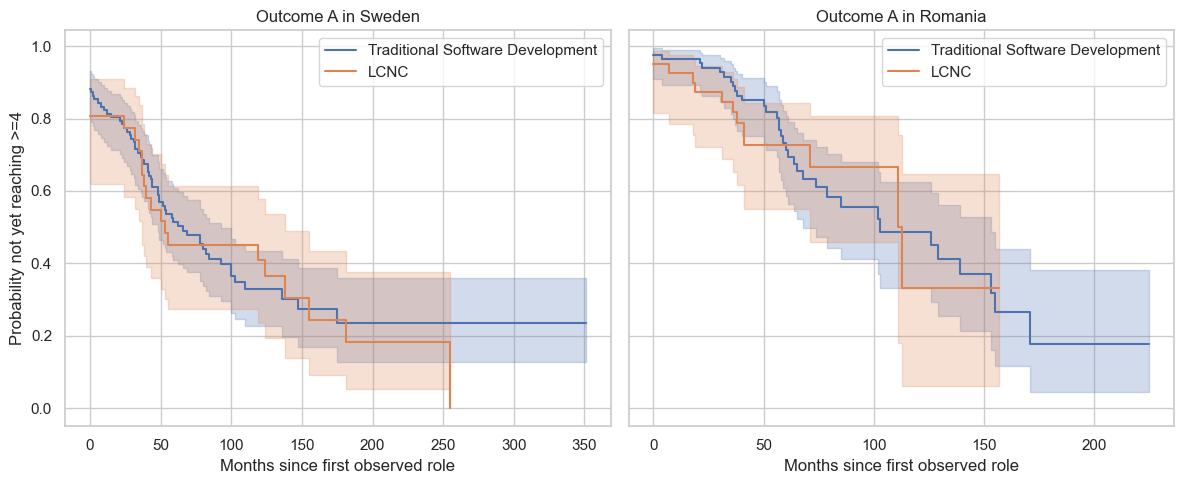

Saved KM Outcome A plot to ../analysis/plots/km_outcome_a_by_country.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
kmf = KaplanMeierFitter()

for ax, country in zip(axes, ["Sweden", "Romania"]):
    d_country = cox_base[cox_base["country"] == country]
    for label in ["Traditional Software Development", "LCNC"]:
        d_group = d_country[d_country["profile_label_primary"] == label]
        if len(d_group) == 0:
            continue
        kmf.fit(
            durations=d_group["time_to_event_a_months"],
            event_observed=d_group["event_a"],
            label=label,
        )
        kmf.plot_survival_function(ax=ax)

    ax.set_title(f"Outcome A in {country}")
    ax.set_xlabel("Months since first observed role")
    ax.set_ylabel("Probability not yet reaching >=4")

plt.tight_layout()
km_a_path = PLOT_DIR / "figure_01_km_outcome_a_by_country.png"
plt.savefig(km_a_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved KM Outcome A plot to {km_a_path}")

### Kaplan-Meier Curves: Outcome B (First Seniority >= 5)
Why this is used:
- Same survival logic as Outcome A, but for a higher progression threshold.

Expected insight:
- Shows whether LCNC vs Traditional differences hold for more advanced seniority transitions.

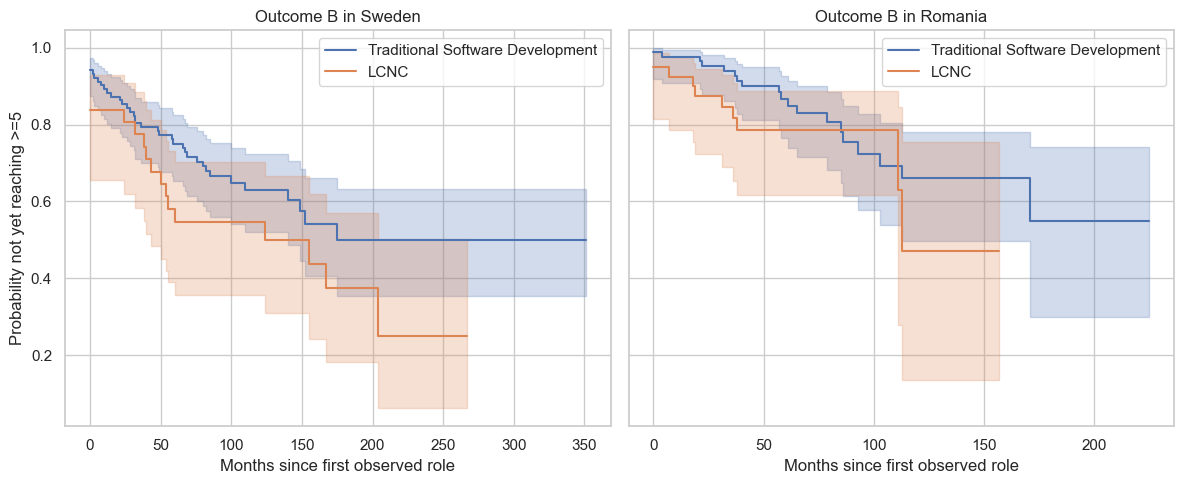

Saved KM Outcome B plot to ../analysis/plots/km_outcome_b_by_country.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
kmf = KaplanMeierFitter()

for ax, country in zip(axes, ["Sweden", "Romania"]):
    d_country = cox_base[cox_base["country"] == country]
    for label in ["Traditional Software Development", "LCNC"]:
        d_group = d_country[d_country["profile_label_primary"] == label]
        if len(d_group) == 0:
            continue
        kmf.fit(
            durations=d_group["time_to_event_b_months"],
            event_observed=d_group["event_b"],
            label=label,
        )
        kmf.plot_survival_function(ax=ax)

    ax.set_title(f"Outcome B in {country}")
    ax.set_xlabel("Months since first observed role")
    ax.set_ylabel("Probability not yet reaching >=5")

plt.tight_layout()
km_b_path = PLOT_DIR / "figure_02_km_outcome_b_by_country.png"
plt.savefig(km_b_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved KM Outcome B plot to {km_b_path}")

### Cumulative Incidence at Fixed Horizons
Why this is used:
- Kaplan-Meier curves are visual; this table gives exact comparable percentages at practical milestones.

Expected insight:
- Directly compares how many profiles have reached each threshold by 1, 2, 3, and 5 years.

,country,profile_type,months,cum_incidence_outcome_a,cum_incidence_outcome_b
0,Sweden,Traditional Software Development,12,0.186275,0.117647
1,Sweden,Traditional Software Development,24,0.225490,0.147059
2,Sweden,Traditional Software Development,36,0.303922,0.205882
3,Sweden,Traditional Software Development,60,0.470588,0.245098
4,Sweden,LCNC,12,0.193548,0.161290
5,Sweden,LCNC,24,0.225806,0.193548
6,Sweden,LCNC,36,0.290323,0.225806
7,Sweden,LCNC,60,0.548387,0.451613
8,Romania,Traditional Software Development,12,0.035714,0.023810
9,Romania,Traditional Software Development,24,0.059524,0.047619


Saved cumulative incidence table to ../analysis/cumulative_incidence_sweden_romania.csv


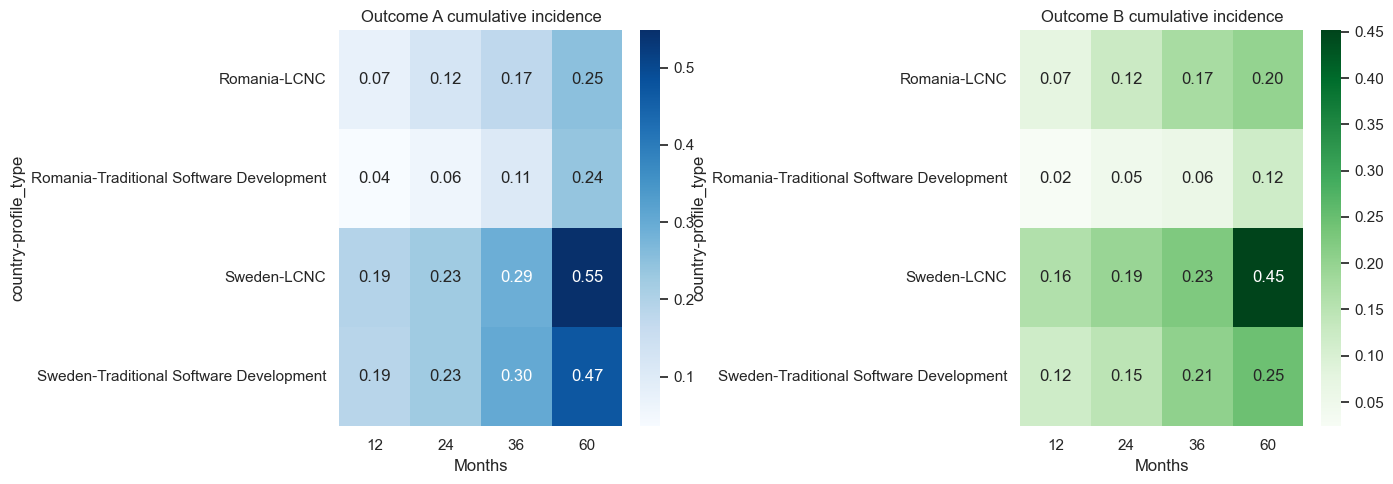

Saved cumulative incidence heatmaps to ../analysis/plots/cumulative_incidence_heatmaps.png


In [9]:
horizons = [12, 24, 36, 60]
rows = []

for country in ["Sweden", "Romania"]:
    for label in ["Traditional Software Development", "LCNC"]:
        d = cox_base[(cox_base["country"] == country) & (cox_base["profile_label_primary"] == label)]
        if len(d) == 0:
            continue

        for h in horizons:
            reached_a = ((d["event_a"] == 1) & (d["time_to_event_a_months"] <= h)).mean()
            reached_b = ((d["event_b"] == 1) & (d["time_to_event_b_months"] <= h)).mean()
            rows.append(
                {
                    "country": country,
                    "profile_type": label,
                    "months": h,
                    "cum_incidence_outcome_a": reached_a,
                    "cum_incidence_outcome_b": reached_b,
                }
            )

cum_incidence = pd.DataFrame(rows)
display(cum_incidence)

cum_incidence_out = ANALYSIS_DIR / "table_02_cumulative_incidence_sweden_romania.csv"
cum_incidence.to_csv(cum_incidence_out, index=False)
print(f"Saved cumulative incidence table to {cum_incidence_out}")

pivot_a = cum_incidence.pivot_table(index=["country", "profile_type"], columns="months", values="cum_incidence_outcome_a")
pivot_b = cum_incidence.pivot_table(index=["country", "profile_type"], columns="months", values="cum_incidence_outcome_b")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_a, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Outcome A cumulative incidence")
axes[0].set_xlabel("Months")

sns.heatmap(pivot_b, annot=True, fmt=".2f", cmap="Greens", ax=axes[1])
axes[1].set_title("Outcome B cumulative incidence")
axes[1].set_xlabel("Months")

plt.tight_layout()
cum_heatmap_path = PLOT_DIR / "figure_03_cumulative_incidence_heatmaps.png"
plt.savefig(cum_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved cumulative incidence heatmaps to {cum_heatmap_path}")

### Cox Proportional Hazards Models
Why this is used:
- Cox estimates adjusted relative progression speed (hazard ratios) while handling censoring.
- Interaction term tests whether LCNC effects differ between Sweden and Romania.

Expected insight:
- Hazard ratio > 1 for LCNC indicates faster milestone attainment than Traditional after adjustment.

Outcome A Cox summary:


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
is_lcnc,0.127068,1.135494,0.245844,-0.354777,0.608914,0.701330,1.838433,0.0,0.516865,6.052504e-01,0.724396
is_romania,-0.223783,0.799489,0.219184,-0.653376,0.205810,0.520286,1.228519,0.0,-1.020983,3.072626e-01,1.702456
lcnc_x_romania,0.154919,1.167563,0.415063,-0.658590,0.968427,0.517581,2.633799,0.0,0.373241,7.089690e-01,0.496206
baseline_seniority,0.557956,1.747098,0.085269,0.390832,0.725080,1.478210,2.064896,0.0,6.543485,6.010141e-11,33.953810
number_of_roles,0.086684,1.090552,0.027657,0.032477,0.140891,1.033010,1.151300,0.0,3.134217,1.723136e-03,9.180748
career_start_year,0.001001,1.001002,0.020234,-0.038657,0.040660,0.962080,1.041498,0.0,0.049488,9.605304e-01,0.058097



Outcome B Cox summary:


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
is_lcnc,0.437027,1.548097,0.290631,-0.132599,1.006652,0.875816,2.736425,0.0,1.503718,1.326539e-01,2.914261
is_romania,0.098193,1.103175,0.292191,-0.474492,0.670877,0.622201,1.955952,0.0,0.336056,7.368284e-01,0.440599
lcnc_x_romania,0.513010,1.670311,0.500788,-0.468517,1.494537,0.625930,4.457273,0.0,1.024405,3.056442e-01,1.710075
baseline_seniority,0.657575,1.930105,0.107111,0.447641,0.867508,1.564617,2.380971,0.0,6.139188,8.294448e-10,30.167135
number_of_roles,0.187075,1.205717,0.031052,0.126215,0.247935,1.134526,1.281377,0.0,6.024618,1.695094e-09,29.135987
career_start_year,-0.007258,0.992768,0.026591,-0.059376,0.044859,0.942352,1.045880,0.0,-0.272965,7.848798e-01,0.349456


Saved Cox Outcome A summary to ../analysis/cox_summary_outcome_a.csv
Saved Cox Outcome B summary to ../analysis/cox_summary_outcome_b.csv


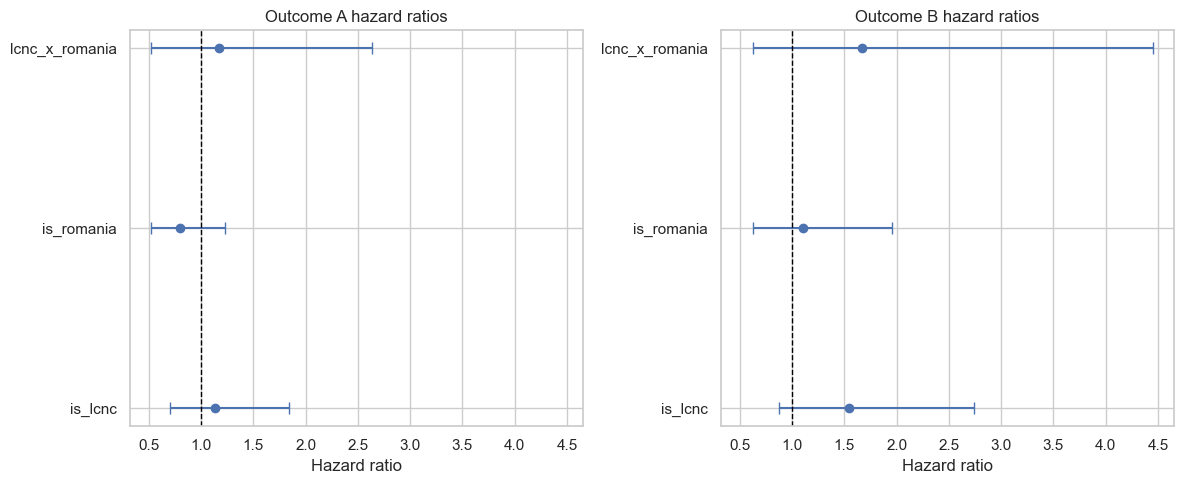

Saved Cox forest plot to ../analysis/plots/cox_forest_key_terms.png


In [10]:
def fit_cox_model(df: pd.DataFrame, duration_col: str, event_col: str):
    model_df = df[
        [
            duration_col,
            event_col,
            "is_lcnc",
            "is_romania",
            "lcnc_x_romania",
            "baseline_seniority",
            "number_of_roles",
            "career_start_year",
        ]
    ].dropna().copy()

    cph = CoxPHFitter()
    cph.fit(model_df, duration_col=duration_col, event_col=event_col)
    return cph, model_df


cph_a, cox_input_a = fit_cox_model(cox_base, "time_to_event_a_months", "event_a")
cph_b, cox_input_b = fit_cox_model(cox_base, "time_to_event_b_months", "event_b")

cox_summary_a = cph_a.summary.copy()
cox_summary_b = cph_b.summary.copy()

cox_summary_a_out = ANALYSIS_DIR / "table_03_cox_summary_outcome_a.csv"
cox_summary_b_out = ANALYSIS_DIR / "table_04_cox_summary_outcome_b.csv"
cox_summary_a.to_csv(cox_summary_a_out)
cox_summary_b.to_csv(cox_summary_b_out)

print("Outcome A Cox summary:")
display(cox_summary_a)
print("\nOutcome B Cox summary:")
display(cox_summary_b)
print(f"Saved Cox Outcome A summary to {cox_summary_a_out}")
print(f"Saved Cox Outcome B summary to {cox_summary_b_out}")

# Forest-style comparison of key coefficients across both models.
key_terms = ["is_lcnc", "is_romania", "lcnc_x_romania"]
plot_rows = []
for outcome_name, summary_df in [("Outcome A", cox_summary_a), ("Outcome B", cox_summary_b)]:
    for term in key_terms:
        if term in summary_df.index:
            plot_rows.append(
                {
                    "outcome": outcome_name,
                    "term": term,
                    "hr": summary_df.loc[term, "exp(coef)"],
                    "hr_low": summary_df.loc[term, "exp(coef) lower 95%"],
                    "hr_high": summary_df.loc[term, "exp(coef) upper 95%"],
                }
            )

forest_df = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ax, outcome in zip(axes, ["Outcome A", "Outcome B"]):
    d = forest_df[forest_df["outcome"] == outcome].copy()
    d = d.sort_values("term")
    ax.errorbar(
        d["hr"],
        d["term"],
        xerr=[d["hr"] - d["hr_low"], d["hr_high"] - d["hr"]],
        fmt="o",
        capsize=4,
    )
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{outcome} hazard ratios")
    ax.set_xlabel("Hazard ratio")

plt.tight_layout()
cox_forest_path = PLOT_DIR / "figure_04_cox_forest_key_terms.png"
plt.savefig(cox_forest_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved Cox forest plot to {cox_forest_path}")

### Career Trajectory Plot Including Broader Role Outcomes
Why this is used:
- This plot keeps all profile types and role labels to show broad career mobility, including transitions into roles classified as Other (for example executive titles).

Expected insight:
- You can see whether people who start in LCNC or Traditional eventually reach high seniority, even if the later role type is not development-labeled.

Saved trajectory endpoint table to ../analysis/trajectory_endpoints_all_profiles.csv


,profile_label,endpoint_job_label,n_profiles,median_endpoint_seniority
0,LCNC,Low-Code/No-Code Development,33,3.0
1,LCNC,Other,38,6.0
2,Mixed,Low-Code/No-Code Development,17,3.0
3,Mixed,Other,7,6.0
4,Mixed,Traditional Software Development,9,3.0
5,Other,Other,10,4.0
6,Traditional Software Development,Low-Code/No-Code Development,4,4.5
7,Traditional Software Development,Other,63,6.0
8,Traditional Software Development,Traditional Software Development,119,3.0


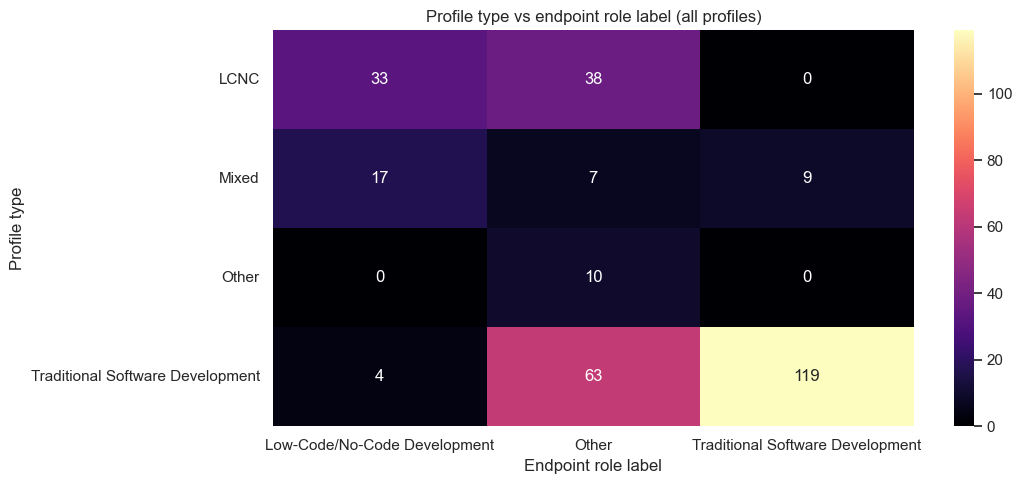

Saved trajectory heatmap to ../analysis/plots/trajectory_endpoint_heatmap_all_profiles.png


In [11]:
all_profiles = profile_analysis.copy()

# Build endpoint role label at each profile's maximum observed seniority.
endpoint_idx = (
    analysis_df.sort_values(["profile_id", "seniority_level", "start_dt"]) 
    .groupby("profile_id")
    .tail(1)
    .set_index("profile_id")
)

all_profiles["endpoint_job_label"] = all_profiles["profile_id"].map(endpoint_idx["job_label"])
all_profiles["endpoint_seniority"] = all_profiles["profile_id"].map(endpoint_idx["seniority_level"])

trajectory_table = (
    all_profiles.groupby(["profile_label", "endpoint_job_label"], dropna=False)
    .agg(
        n_profiles=("profile_id", "count"),
        median_endpoint_seniority=("endpoint_seniority", "median"),
    )
    .reset_index()
)

trajectory_out = ANALYSIS_DIR / "table_05_trajectory_endpoints_all_profiles.csv"
trajectory_table.to_csv(trajectory_out, index=False)
print(f"Saved trajectory endpoint table to {trajectory_out}")

display(trajectory_table)

heat = trajectory_table.pivot_table(
    index="profile_label",
    columns="endpoint_job_label",
    values="n_profiles",
    fill_value=0,
)

plt.figure(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="magma")
plt.title("Profile type vs endpoint role label (all profiles)")
plt.xlabel("Endpoint role label")
plt.ylabel("Profile type")
plt.tight_layout()
trajectory_plot_path = PLOT_DIR / "figure_05_trajectory_endpoint_heatmap_all_profiles.png"
plt.savefig(trajectory_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved trajectory heatmap to {trajectory_plot_path}")

### Quick Interpretation Helper
Why this is used:
- Produces compact text snippets from model outputs for rapid reporting in your thesis draft.

Expected insight:
- Immediate statements on direction and strength of LCNC effects for both outcomes.

In [12]:
def interpretation_line(summary_df: pd.DataFrame, term: str, label: str) -> str:
    if term not in summary_df.index:
        return f"{label}: term '{term}' not estimated."
    hr = summary_df.loc[term, "exp(coef)"]
    lo = summary_df.loc[term, "exp(coef) lower 95%"]
    hi = summary_df.loc[term, "exp(coef) upper 95%"]
    direction = "faster" if hr > 1 else "slower"
    return f"{label}: HR={hr:.2f} (95% CI {lo:.2f}-{hi:.2f}) -> {direction} progression vs reference."

insight_lines = [
    interpretation_line(cox_summary_a, "is_lcnc", "Outcome A LCNC main effect"),
    interpretation_line(cox_summary_a, "lcnc_x_romania", "Outcome A LCNC x Romania interaction"),
    interpretation_line(cox_summary_b, "is_lcnc", "Outcome B LCNC main effect"),
    interpretation_line(cox_summary_b, "lcnc_x_romania", "Outcome B LCNC x Romania interaction"),
]

for line in insight_lines:
    print("- " + line)

insights_out = ANALYSIS_DIR / "note_01_model_interpretation_lines.txt"
with open(insights_out, "w", encoding="utf-8") as f:
    for line in insight_lines:
        f.write(line + "\n")

print(f"Saved interpretation helper text to {insights_out}")

- Outcome A LCNC main effect: HR=1.14 (95% CI 0.70-1.84) -> faster progression vs reference.
- Outcome A LCNC x Romania interaction: HR=1.17 (95% CI 0.52-2.63) -> faster progression vs reference.
- Outcome B LCNC main effect: HR=1.55 (95% CI 0.88-2.74) -> faster progression vs reference.
- Outcome B LCNC x Romania interaction: HR=1.67 (95% CI 0.63-4.46) -> faster progression vs reference.
Saved interpretation helper text to ../analysis/model_interpretation_lines.txt


In [ ]:
# Step 1 only: Proportional hazards diagnostics for both Cox models.
import io
import contextlib
import pandas as pd
from lifelines import CoxPHFitter

# Rebuild model objects only if they are not available in memory.
if "cph_a" not in globals() or "cph_b" not in globals() or "cox_input_a" not in globals() or "cox_input_b" not in globals():
    base = pd.read_csv(ANALYSIS_DIR / "table_01_analysis_dataset_sweden_romania.csv")
    strict = base[base["profile_label_primary"].isin(["LCNC", "Traditional Software Development"])].copy()
    strict["is_lcnc"] = (strict["profile_label_primary"] == "LCNC").astype(int)
    strict["is_romania"] = (strict["country"] == "Romania").astype(int)
    strict["lcnc_x_romania"] = strict["is_lcnc"] * strict["is_romania"]

    def _fit(df, duration_col, event_col):
        cols = [
            duration_col,
            event_col,
            "is_lcnc",
            "is_romania",
            "lcnc_x_romania",
            "baseline_seniority",
            "number_of_roles",
            "career_start_year",
        ]
        model_df = df[cols].dropna().copy()
        cph = CoxPHFitter()
        cph.fit(model_df, duration_col=duration_col, event_col=event_col)
        return cph, model_df

    cph_a, cox_input_a = _fit(strict, "time_to_event_a_months", "event_a")
    cph_b, cox_input_b = _fit(strict, "time_to_event_b_months", "event_b")


def _ph_report(cph_model, model_df, label):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        cph_model.check_assumptions(model_df, p_value_threshold=0.05, show_plots=False)
    return f"=== {label} ===\n" + buf.getvalue().strip() + "\n"

report_a = _ph_report(cph_a, cox_input_a, "Outcome A")
report_b = _ph_report(cph_b, cox_input_b, "Outcome B")

out_path = ANALYSIS_DIR / "note_03_ph_assumptions_check.txt"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(report_a)
    f.write("\n")
    f.write(report_b)

print(f"Saved PH diagnostics to {out_path}")
print("\nPreview (first lines):")
preview_lines = (report_a + "\n" + report_b).splitlines()[:30]
for line in preview_lines:
    print(line)